# CNN + Temporal Attention — Key Classifier (No Augmentation)

Classifies MIDI files into one of **24 musical keys** (12 major + 12 minor)  
using the **raw, unbalanced** piano-roll dataset — no pitch-shift augmentation,  
no undersampling. `WeightedRandomSampler` is used at training time to compensate  
for the severe class imbalance in the Lakh MIDI corpus.

In [8]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

## 1. Configuration

In [9]:
SCRIPTS_DIR    = Path(os.path.abspath(''))
PROJECT_DIR    = SCRIPTS_DIR.parent
METADATA_CSV   = PROJECT_DIR / 'data' / 'processed_data' / 'lmd_full_metadata.csv'
PIANO_ROLL_DIR = PROJECT_DIR / 'data' / 'processed_data' / 'spectrograms' / 'piano_roll'
MODEL_SAVE_PATH = PROJECT_DIR / 'data' / 'processed_data' / 'cnn_attention_key_noaug.pt'

# ── Data filters ──────────────────────────────────────────────────────────────
BPM_MIN       = 30       # initial_bpm lower bound
BPM_MAX       = 240      # initial_bpm upper bound
N_NOTES_MIN   = 50       # n_notes lower bound
N_NOTES_MAX   = 50_000   # n_notes upper bound
DURATION_MIN  = 15       # duration_s lower bound  (seconds)
DURATION_MAX  = 600      # duration_s upper bound  (seconds)

# ── Model / training hyperparameters ─────────────────────────────────────────
SEGMENT_LEN     = 512   # frames per sample  (100 fps → ~5.12 s)
N_PITCH         = 128   # piano-roll pitch dimension
D_MODEL         = 256   # attention hidden dimension
N_HEADS         = 4     # number of attention heads
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
N_EPOCHS        = 30
PATIENCE        = 5     # early-stopping patience (val-loss)
MIN_CLASS_COUNT = 1000   # drop classes with fewer than 100 samples

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device (MPS → CUDA → CPU) ─────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

N_WORKERS = min(8, os.cpu_count())
print(f'Device: {DEVICE}   DataLoader workers: {N_WORKERS}')

Device: mps   DataLoader workers: 8


## 2. Load Metadata & Label Encoding

In [10]:
df = pd.read_csv(METADATA_CSV, parse_dates=False)

# Keep only rows that have a key label AND whose .npz file exists on disk
df = df[df['key_name'].notna()].copy()
df['stem']     = df['file'].str[:-4]   # strip '.mid'
df['npz_path'] = df['stem'].apply(lambda s: str(PIANO_ROLL_DIR / f'{s}.npz'))
df = df[df['npz_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Labeled files with .npz present : {len(df):,}')

# ── Configurable filters ──────────────────────────────────────────────────────
before = len(df)
df = df[
    df['initial_bpm'].between(BPM_MIN, BPM_MAX) &
    df['n_notes'].between(N_NOTES_MIN, N_NOTES_MAX) &
    df['duration_s'].between(DURATION_MIN, DURATION_MAX)
].reset_index(drop=True)
print(f'After filters'
      f' (bpm [{BPM_MIN}, {BPM_MAX}],'
      f' n_notes [{N_NOTES_MIN:,}, {N_NOTES_MAX:,}],'
      f' duration [{DURATION_MIN}, {DURATION_MAX}] s)'
      f' : {len(df):,}  (removed {before - len(df):,})')

# Drop rare keys — need at least MIN_CLASS_COUNT labeled samples to train on a class
key_counts = df['key_name'].value_counts()
keep_keys  = key_counts[key_counts >= MIN_CLASS_COUNT].index
dropped    = key_counts[key_counts < MIN_CLASS_COUNT]
df = df[df['key_name'].isin(keep_keys)].reset_index(drop=True)

print(f'After min-count filter (>={MIN_CLASS_COUNT:,}) : {len(df):,}')
print(f'Classes kept    : {len(keep_keys)}')
print(f'Classes dropped : {len(dropped)}'
      + (f'  -> {list(dropped.index)}' if len(dropped) else ''))

# Label encoding — alphabetical sort for reproducibility
classes      = sorted(df['key_name'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df['label']  = df['key_name'].map(class_to_idx)
N_CLASSES    = len(classes)

print(f'\nClasses ({N_CLASSES}):')
print(df['key_name'].value_counts().to_string())

Labeled files with .npz present : 86,451
After filters (bpm [30, 240], n_notes [50, 50,000], duration [15, 600] s) : 84,110  (removed 2,341)
After min-count filter (>=1,000) : 79,699
Classes kept    : 9
Classes dropped : 15  -> ['C# major', 'A minor', 'B major', 'F# major', 'D minor', 'E minor', 'C minor', 'G minor', 'B minor', 'F minor', 'A# minor', 'F# minor', 'C# minor', 'D# minor', 'G# minor']

Classes (9):
key_name
C major     51856
G major      6009
F major      5213
D major      3969
A# major     3232
D# major     3104
A major      2726
E major      2025
G# major     1565


## 3. Dataset

In [11]:
class PianoRollDataset(Dataset):
    """
    Loads pre-saved uint8 piano-roll .npz files and returns fixed-length crops.

    Train mode (augment=True):  random crop along the time axis.
    Eval  mode (augment=False): center crop.
    Short files (<SEGMENT_LEN frames) are zero-padded on the right.

    Returns
    -------
    roll  : torch.Tensor  shape (1, 128, SEGMENT_LEN), dtype float32
    label : int
    """

    def __init__(self, df: pd.DataFrame, segment_len: int = SEGMENT_LEN, augment: bool = False):
        self.df          = df.reset_index(drop=True)
        self.segment_len = segment_len
        self.augment     = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row  = self.df.iloc[idx]
        # Load uint8 and normalise to [0, 1]
        roll = np.load(row['npz_path'])['roll'].astype(np.float32) / 127.0  # (128, T)

        T = roll.shape[1]
        L = self.segment_len

        if T >= L:
            # Random crop during training; center crop during eval
            start = random.randint(0, T - L) if self.augment else (T - L) // 2
            roll  = roll[:, start : start + L]
        else:
            # Zero-pad on the right to reach SEGMENT_LEN
            pad  = np.zeros((128, L - T), dtype=np.float32)
            roll = np.concatenate([roll, pad], axis=1)

        # Add channel dimension: (128, L) → (1, 128, L)
        roll = roll[np.newaxis]
        return torch.from_numpy(roll), int(row['label'])

## 4. Train / Val / Test Split

In [12]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

train_ds = PianoRollDataset(train_df, augment=True)
val_ds   = PianoRollDataset(val_df,   augment=False)
test_ds  = PianoRollDataset(test_df,  augment=False)

# WeightedRandomSampler — dataset is highly imbalanced (C major: ~53k vs G# minor: ~44).
# Inverse-frequency weights ensure every class is sampled equally often per epoch,
# preventing the model from collapsing to majority-class predictions.
class_counts   = train_df['label'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[lbl] for lbl in train_df['label']]
sampler        = WeightedRandomSampler(
    sample_weights, num_samples=len(train_df), replacement=True
)

# Use 'fork' context so the notebook-defined PianoRollDataset can be pickled
# across worker processes without AttributeError (same pattern as Stage 2).
MP_CONTEXT = 'fork' if N_WORKERS > 0 else None

# persistent_workers=True keeps fork workers alive between epochs so that
# a new fork() is never issued while a prior DataLoader iterator is still
# in scope.  Without it, val/test workers inherit the train iterator and
# trigger AssertionError('can only test a child process') on GC cleanup.
PW = N_WORKERS > 0   # persistent_workers requires num_workers > 0

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)

print(f'Batches  Train: {len(train_loader):,}  Val: {len(val_loader):,}  Test: {len(test_loader):,}')

Train: 63,759  Val: 7,970  Test: 7,970
Batches  Train: 997  Val: 125  Test: 125


## 5. Model — Simple CNN

In [ ]:
class CNNBlock(nn.Module):
    """Two Conv2d layers (BN + ReLU each) followed by MaxPool2d(2, 2)."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

In [13]:
class SimpleCNN(nn.Module):
    """
    3-block CNN backbone + global average pool + FC classifier.
    Baseline model — no temporal attention.

    Input  (B, 1, 128, T)
      ↓  3 × CNNBlock  [Conv→BN→ReLU→Conv→BN→ReLU→MaxPool2d(2,2)]
    (B, 128, 16, T//8)
      ↓  AdaptiveAvgPool2d(1, 1)  →  flatten
    (B, 128)
      ↓  Dropout → Linear(128, 256) → ReLU → Dropout → Linear(256, N_CLASSES)
    (B, N_CLASSES)
    """

    def __init__(self, n_classes: int, n_pitch: int = N_PITCH):
        super().__init__()
        self.cnn = nn.Sequential(
            CNNBlock(1,   32),    # (B,  32, 64, T//2)
            CNNBlock(32,  64),    # (B,  64, 32, T//4)
            CNNBlock(64, 128),    # (B, 128, 16, T//8)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.cnn(x)      # (B, 128, 16, T//8)
        feat = self.pool(feat)  # (B, 128, 1, 1)
        feat = feat.flatten(1)  # (B, 128)
        return self.head(feat)

## 6. Model — CNN with Temporal Attention

```
Input  (B, 1, 128, T)
  ↓  3 × CNNBlock  [Conv→BN→ReLU→Conv→BN→ReLU→MaxPool2d(2,2)]
(B, 128, 16, T//8)          pitch: 128→16   time: T→T//8
  ↓  reshape + Linear projection
(B, T//8, d_model=256)
  ↓  + learnable positional embedding
  ↓  MultiheadAttention (4 heads) + residual + LayerNorm
(B, T//8, 256)
  ↓  global average pool over time
(B, 256)
  ↓  Dropout → Linear(256,256) → ReLU → Dropout → Linear(256, 24)
(B, 24)
```

In [ ]:
class TemporalAttention(nn.Module):
    """Multi-head self-attention + residual + LayerNorm over the time axis."""

    def __init__(self, d_model: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        out, weights = self.attn(x, x, x)
        x = self.norm(x + self.drop(out))
        return x, weights


class CNNWithAttention(nn.Module):
    """
    3-block CNN backbone + temporal self-attention + global avg pool + classifier.
    """

    def __init__(
        self,
        n_classes : int,
        T         : int = SEGMENT_LEN,
        n_pitch   : int = N_PITCH,
        d_model   : int = D_MODEL,
        n_heads   : int = N_HEADS,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            CNNBlock(1,   32),
            CNNBlock(32,  64),
            CNNBlock(64, 128),
        )
        pitch_pooled = n_pitch // 8
        feat_dim     = 128 * pitch_pooled
        t_steps      = T   // 8

        self.proj      = nn.Linear(feat_dim, d_model, bias=False)
        self.pos_embed = nn.Parameter(torch.zeros(1, t_steps, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.attn_layer = TemporalAttention(d_model, n_heads)
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(d_model, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        feat = self.cnn(x)
        B, C, H, W = feat.shape
        feat = feat.permute(0, 3, 1, 2).reshape(B, W, C * H)
        feat = self.proj(feat) + self.pos_embed
        feat, attn_weights = self.attn_layer(feat)
        feat = feat.mean(dim=1)
        logits = self.head(feat)
        if return_attention:
            return logits, attn_weights
        return logits

## 7. Simple CNN — Training

In [15]:
MODEL_SAVE_SIMPLE = PROJECT_DIR / 'data' / 'processed_data' / 'cnn_simple_key_noaug.pt'

model_simple = SimpleCNN(n_classes=N_CLASSES).to(DEVICE)
print(f'SimpleCNN — trainable parameters: '
      f'{sum(p.numel() for p in model_simple.parameters() if p.requires_grad):,}')

criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, optimizer=None, train=True):
    """One full pass over loader. Returns (avg_loss, accuracy)."""
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False, desc='train' if train else 'eval'):
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


optimizer_s = torch.optim.Adam(model_simple.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_s = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s, T_max=N_EPOCHS, eta_min=1e-5
)

history_simple   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model_simple, train_loader, optimizer_s, train=True)
    va_loss, va_acc = run_epoch(model_simple, val_loader,   train=False)
    scheduler_s.step()

    history_simple['train_loss'].append(tr_loss)
    history_simple['val_loss'].append(va_loss)
    history_simple['train_acc'].append(tr_acc)
    history_simple['val_acc'].append(va_acc)

    flag = ''
    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_counter = 0
        torch.save(model_simple.state_dict(), MODEL_SAVE_SIMPLE)
        flag = '  <- best'
    else:
        patience_counter += 1

    print(
        f'Epoch {epoch:3d}/{N_EPOCHS}  '
        f'train loss {tr_loss:.4f}  acc {tr_acc:.4f} | '
        f'val loss {va_loss:.4f}  acc {va_acc:.4f}{flag}'
    )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Model saved   -> {MODEL_SAVE_SIMPLE}')

SimpleCNN — trainable parameters: 322,217


train:   0%|          | 0/997 [00:00<?, ?it/s]

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch   1/30  train loss 1.9013  acc 0.2714 | val loss 2.1224  acc 0.1353  <- best


train:   0%|          | 0/997 [00:00<?, ?it/s]

...

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  23/30  train loss 1.4647  acc 0.5021 | val loss 1.7466  acc 0.2977


train:   0%|          | 0/997 [00:00<?, ?it/s]

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  24/30  train loss 1.4686  acc 0.5009 | val loss 1.7522  acc 0.2990
Early stopping at epoch 24.

Best val loss : 1.6600
Model saved   -> /Users/yhkim/GU_work/02_Spring_2026/6600_work/04_PROJ/6600_Project/data/processed_data/cnn_simple_key_noaug.pt


## 8. Simple CNN — Evaluation

In [16]:
model_simple.load_state_dict(torch.load(MODEL_SAVE_SIMPLE, map_location=DEVICE, weights_only=True))
test_loss, test_acc = run_epoch(model_simple, test_loader, train=False)
print(f'[Simple CNN]  Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}')

eval:   0%|          | 0/125 [00:00<?, ?it/s]

[Simple CNN]  Test loss: 1.6427  |  Test accuracy: 0.3227


In [17]:
preds_simple, labels_simple = [], []
model_simple.eval()
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Collecting predictions'):
        logits = model_simple(x.to(DEVICE))
        preds_simple.extend(logits.argmax(dim=1).cpu().tolist())
        labels_simple.extend(y.tolist())

preds_simple  = np.array(preds_simple)
labels_simple = np.array(labels_simple)
print(classification_report(labels_simple, preds_simple, target_names=classes, digits=3))

              precision    recall  f1-score   support

     A major      0.195     0.500     0.280       272
    A# major      0.238     0.536     0.329       323
     C major      0.845     0.198     0.321      5185
     D major      0.234     0.516     0.322       397
    D# major      0.289     0.605     0.391       311
     E major      0.104     0.493     0.172       203
     F major      0.284     0.623     0.390       522
     G major      0.315     0.549     0.400       601
    G# major      0.135     0.564     0.217       156

    accuracy                          0.323      7970
   macro avg      0.293     0.509     0.314      7970
weighted avg      0.637     0.323     0.327      7970



## 9. Simple CNN — Visualizations

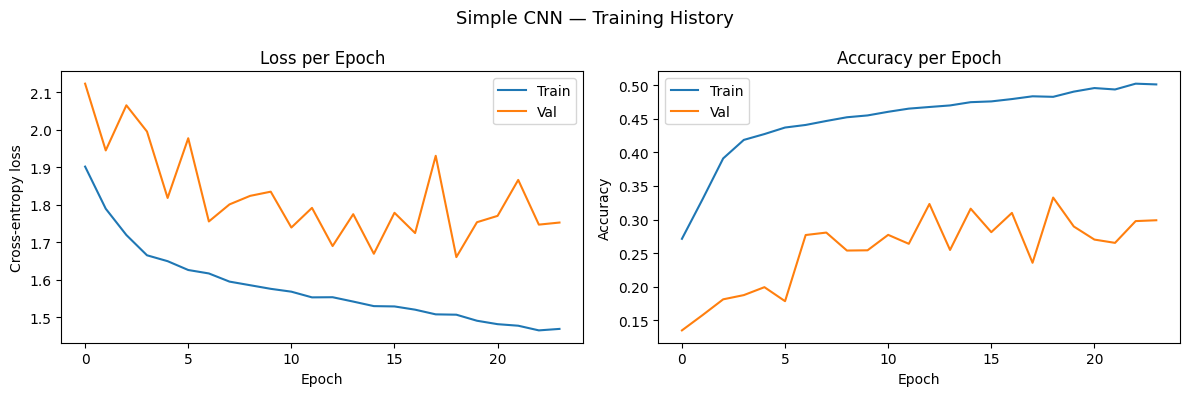

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_simple['train_loss'], label='Train')
axes[0].plot(history_simple['val_loss'],   label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(history_simple['train_acc'], label='Train')
axes[1].plot(history_simple['val_acc'],   label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Simple CNN — Training History', fontsize=13)
plt.tight_layout()
plt.show()

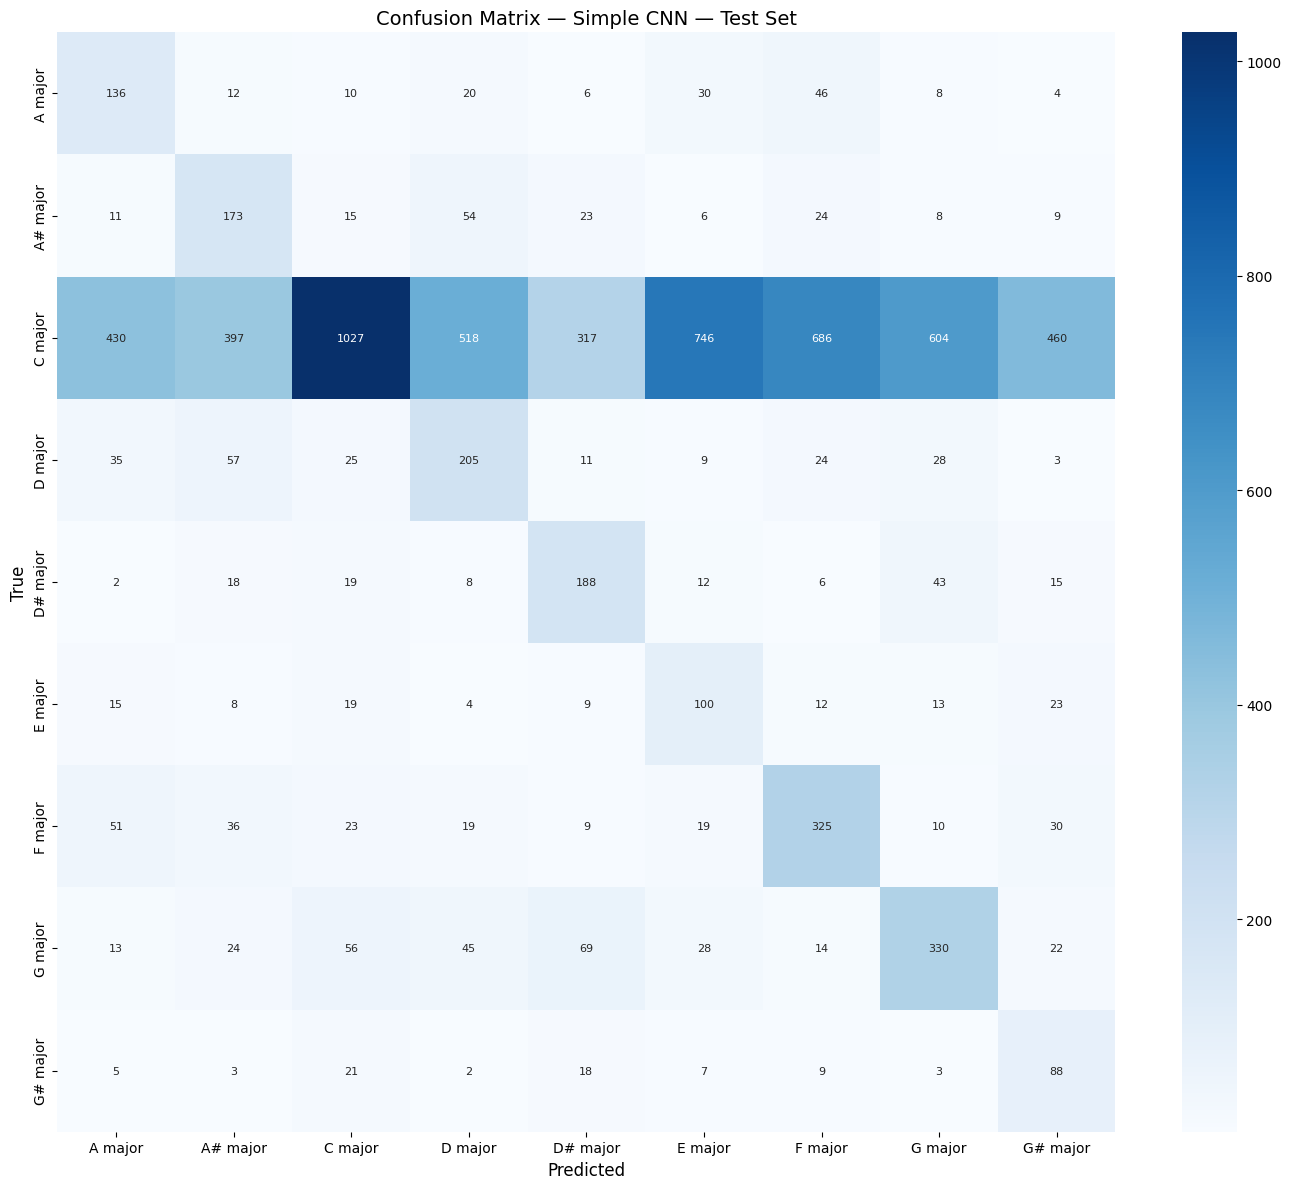

In [19]:
cm = confusion_matrix(labels_simple, preds_simple)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes, ax=ax,
    annot_kws={'size': 8},
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix — Simple CNN — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## 10. CNN with Attention — Training

In [20]:
MODEL_SAVE_ATTN = PROJECT_DIR / 'data' / 'processed_data' / 'cnn_attention_key_noaug.pt'

model_attn = CNNWithAttention(n_classes=N_CLASSES).to(DEVICE)
print(f'CNNWithAttention — trainable parameters: '
      f'{sum(p.numel() for p in model_attn.parameters() if p.requires_grad):,}')

optimizer_a = torch.optim.Adam(model_attn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_a, T_max=N_EPOCHS, eta_min=1e-5
)

history_attn     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model_attn, train_loader, optimizer_a, train=True)
    va_loss, va_acc = run_epoch(model_attn, val_loader,   train=False)
    scheduler_a.step()

    history_attn['train_loss'].append(tr_loss)
    history_attn['val_loss'].append(va_loss)
    history_attn['train_acc'].append(tr_acc)
    history_attn['val_acc'].append(va_acc)

    flag = ''
    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_counter = 0
        torch.save(model_attn.state_dict(), MODEL_SAVE_ATTN)
        flag = '  <- best'
    else:
        patience_counter += 1

    print(
        f'Epoch {epoch:3d}/{N_EPOCHS}  '
        f'train loss {tr_loss:.4f}  acc {tr_acc:.4f} | '
        f'val loss {va_loss:.4f}  acc {va_acc:.4f}{flag}'
    )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Model saved   -> {MODEL_SAVE_ATTN}')

CNNWithAttention — trainable parameters: 1,159,337


train:   0%|          | 0/997 [00:00<?, ?it/s]

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch   1/30  train loss 1.4125  acc 0.5192 | val loss 1.7933  acc 0.2897  <- best


train:   0%|          | 0/997 [00:00<?, ?it/s]

...

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  10/30  train loss 1.2288  acc 0.6064 | val loss 1.7814  acc 0.3235


train:   0%|          | 0/997 [00:00<?, ?it/s]

eval:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  11/30  train loss 1.2117  acc 0.6147 | val loss 1.8371  acc 0.3108
Early stopping at epoch 11.

Best val loss : 1.6415
Model saved   -> /Users/yhkim/GU_work/02_Spring_2026/6600_work/04_PROJ/6600_Project/data/processed_data/cnn_attention_key_noaug.pt


## 11. CNN with Attention — Evaluation

In [21]:
model_attn.load_state_dict(torch.load(MODEL_SAVE_ATTN, map_location=DEVICE, weights_only=True))
test_loss, test_acc = run_epoch(model_attn, test_loader, train=False)
print(f'[CNN + Attention]  Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}')

eval:   0%|          | 0/125 [00:00<?, ?it/s]

[CNN + Attention]  Test loss: 1.6323  |  Test accuracy: 0.3486


In [22]:
preds_attn, labels_attn = [], []
model_attn.eval()
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Collecting predictions'):
        logits = model_attn(x.to(DEVICE))
        preds_attn.extend(logits.argmax(dim=1).cpu().tolist())
        labels_attn.extend(y.tolist())

preds_attn  = np.array(preds_attn)
labels_attn = np.array(labels_attn)
print(classification_report(labels_attn, preds_attn, target_names=classes, digits=3))

              precision    recall  f1-score   support

     A major      0.210     0.651     0.317       272
    A# major      0.323     0.567     0.411       323
     C major      0.878     0.179     0.298      5185
     D major      0.270     0.610     0.374       397
    D# major      0.316     0.756     0.446       311
     E major      0.195     0.616     0.297       203
     F major      0.301     0.701     0.422       522
     G major      0.268     0.686     0.385       601
    G# major      0.231     0.692     0.346       156

    accuracy                          0.349      7970
   macro avg      0.332     0.606     0.366      7970
weighted avg      0.667     0.349     0.328      7970



## 12. CNN with Attention — Visualizations

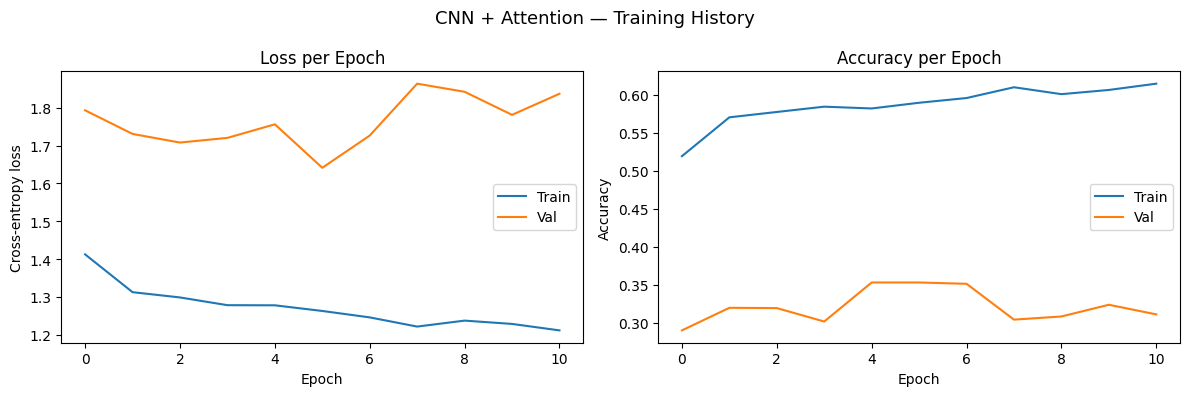

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_attn['train_loss'], label='Train')
axes[0].plot(history_attn['val_loss'],   label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(history_attn['train_acc'], label='Train')
axes[1].plot(history_attn['val_acc'],   label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('CNN + Attention — Training History', fontsize=13)
plt.tight_layout()
plt.show()

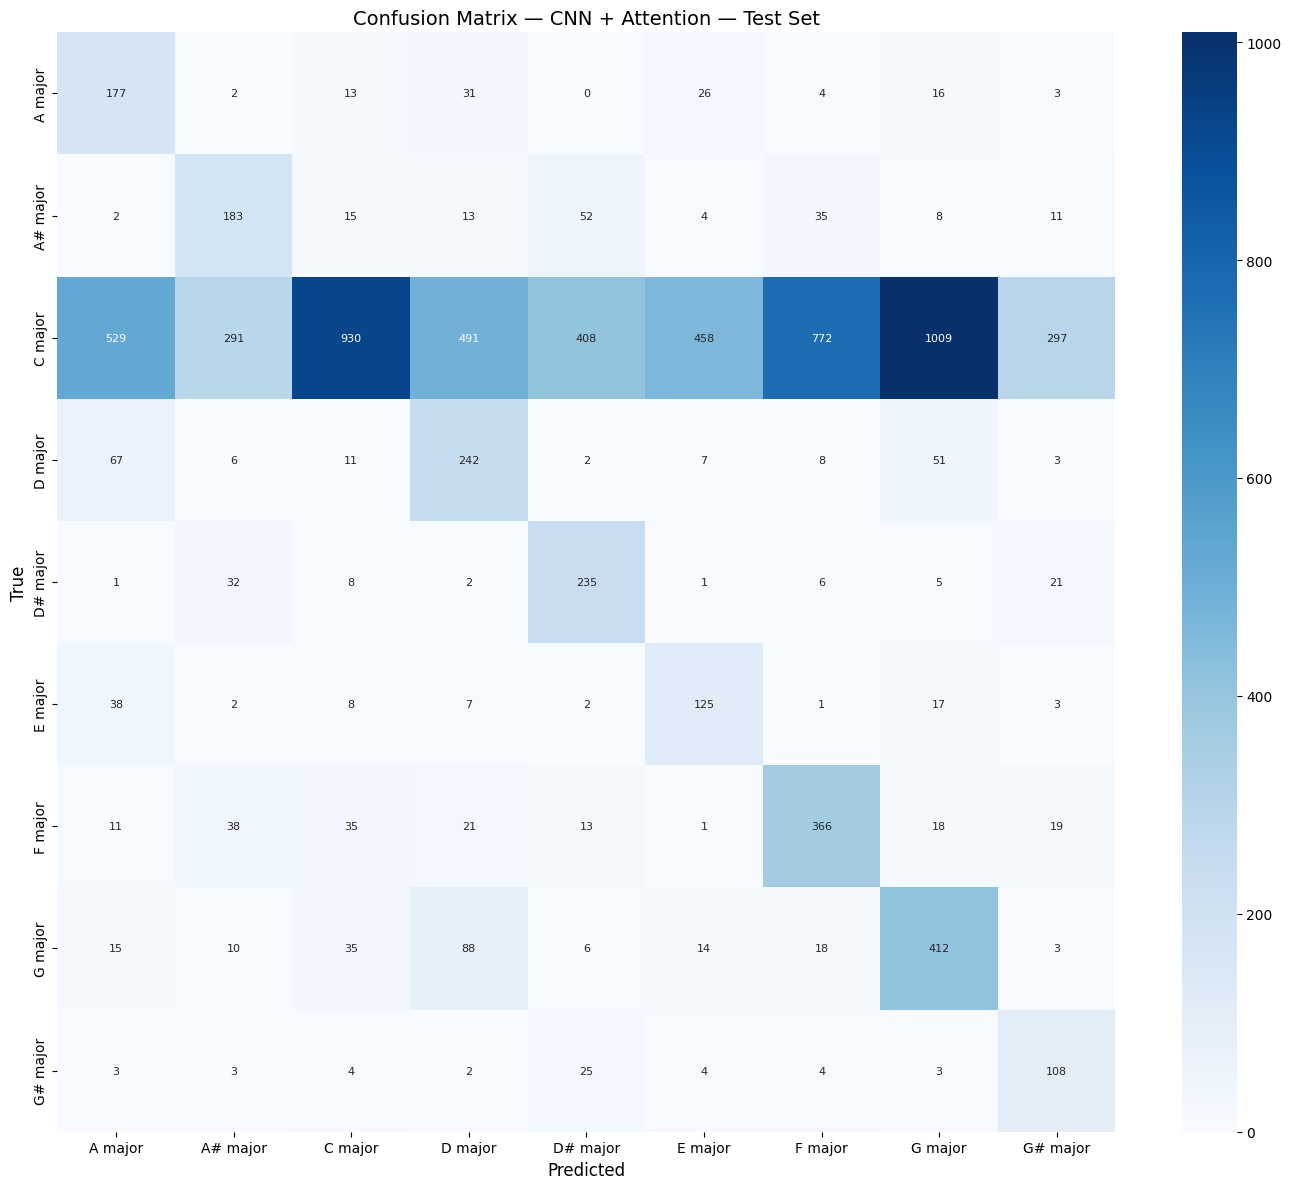

In [24]:
cm = confusion_matrix(labels_attn, preds_attn)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes, ax=ax,
    annot_kws={'size': 8},
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix — CNN + Attention — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

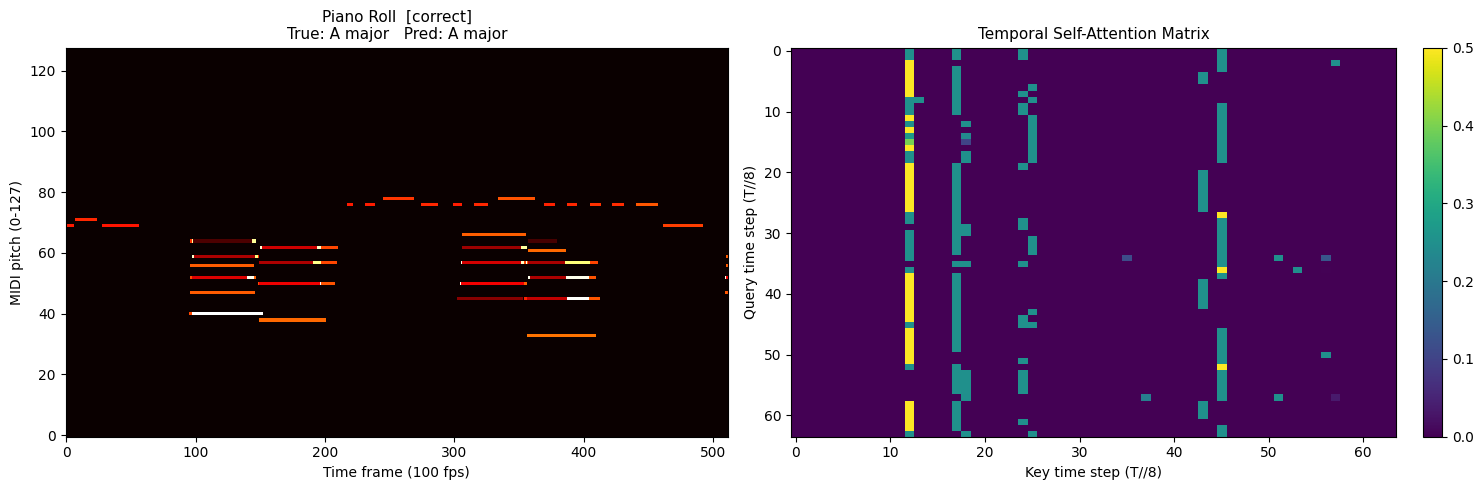

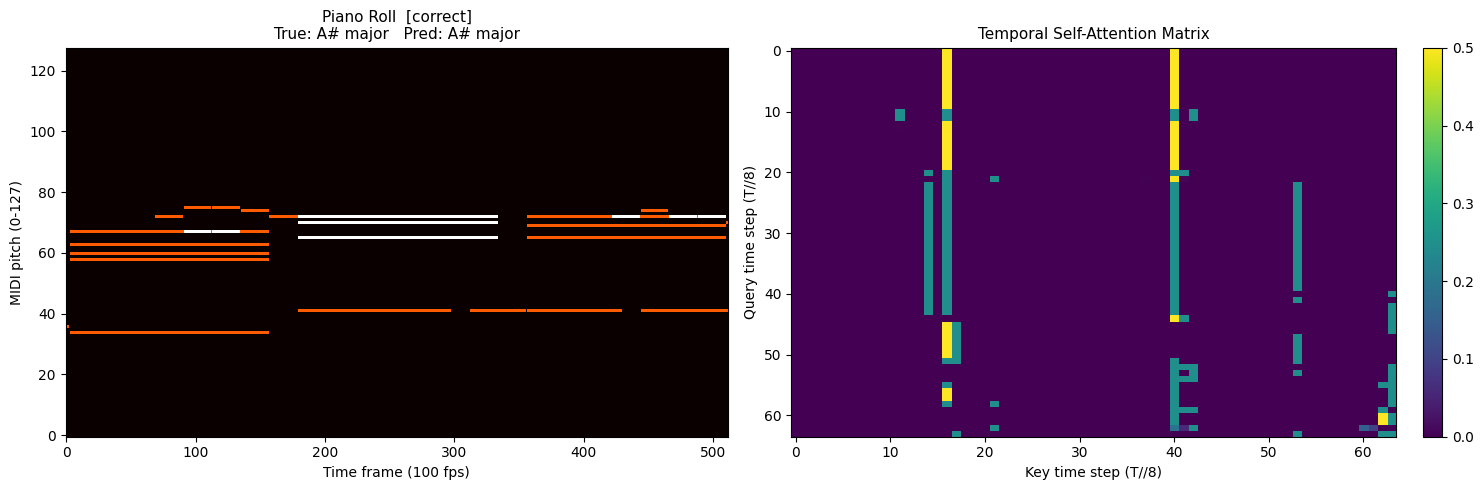

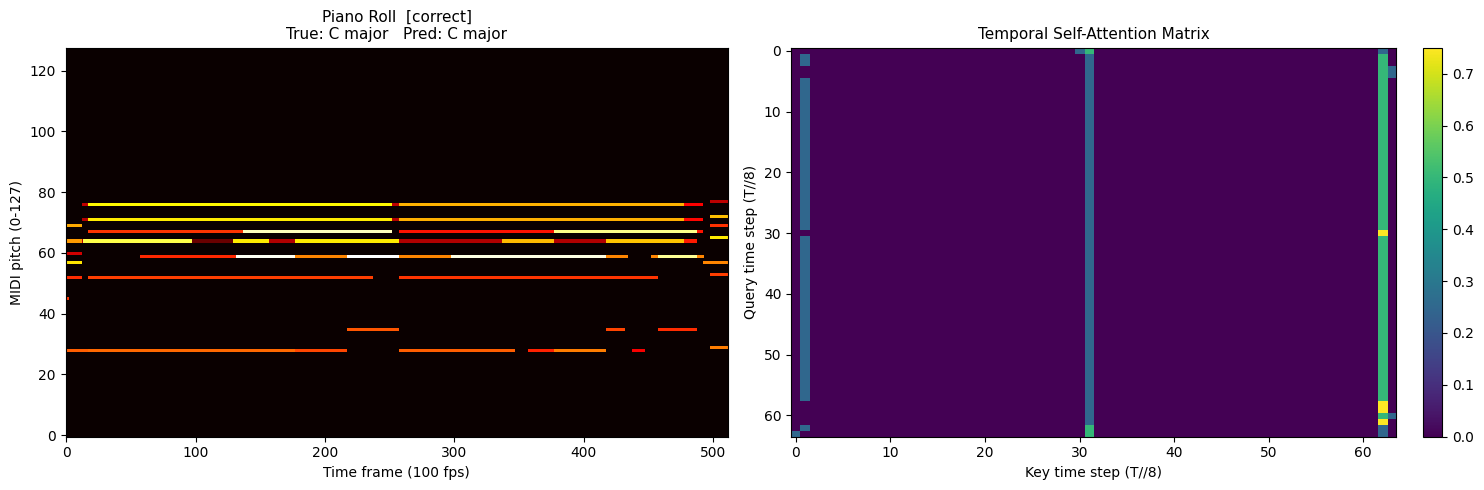

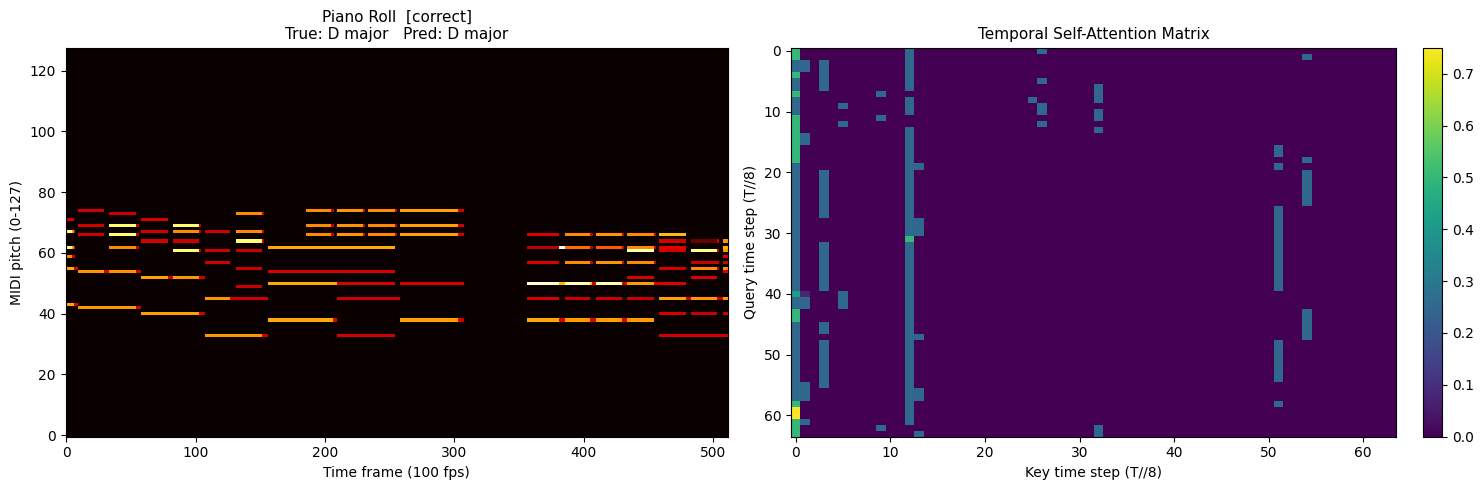

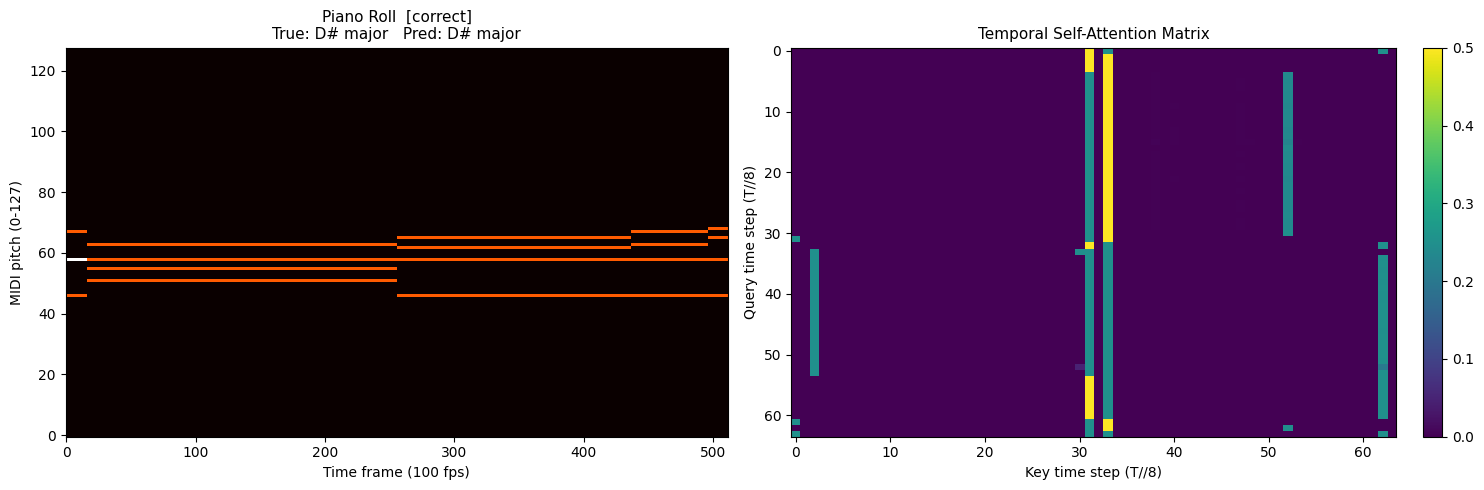

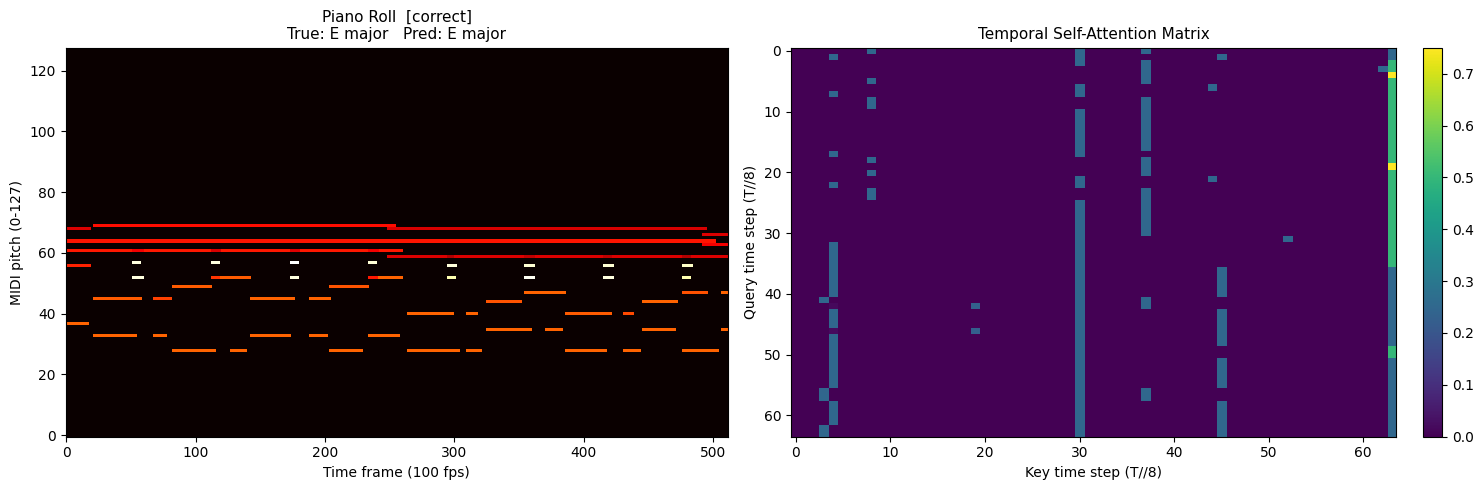

In [25]:
def visualize_attention(model, dataset, idx):
    """Plot piano roll and temporal self-attention matrix for one test sample."""
    model.eval()
    x, true_label = dataset[idx]
    with torch.no_grad():
        logits, attn = model(x.unsqueeze(0).to(DEVICE), return_attention=True)
    pred_label = logits.argmax(dim=1).item()
    attn_np    = attn[0].cpu().float().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(x[0].numpy(), aspect='auto', origin='lower',
                   cmap='hot', interpolation='nearest')
    correct = 'correct' if true_label == pred_label else 'WRONG'
    axes[0].set_title(
        f'Piano Roll  [{correct}]\n'
        f'True: {classes[true_label]}   Pred: {classes[pred_label]}',
        fontsize=11,
    )
    axes[0].set_xlabel('Time frame (100 fps)')
    axes[0].set_ylabel('MIDI pitch (0-127)')

    im = axes[1].imshow(attn_np, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[1].set_title('Temporal Self-Attention Matrix', fontsize=11)
    axes[1].set_xlabel('Key time step (T//8)')
    axes[1].set_ylabel('Query time step (T//8)')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


correct_by_label = {lbl: [] for lbl in range(N_CLASSES)}
for i, (p, t) in enumerate(zip(preds_attn, labels_attn)):
    if p == t:
        correct_by_label[t].append(i)

shown = set()
for lbl in sorted(correct_by_label.keys()):
    if not correct_by_label[lbl]:
        continue
    visualize_attention(model_attn, test_ds, correct_by_label[lbl][0])
    shown.add(lbl)
    if len(shown) >= 6:
        break